# SI 630 Homework 3

This notebook covers:

- **Part 1** reflection and annotation-file loading
- **Part 2** model training with RoBERTa + Hugging Face `Trainer`
- **Problem 6** Weights & Biases logging and model selection
- **Problem 7** evaluation on the 100 manually annotated examples



## Load files


In [3]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import torch
import wandb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    ProgressCallback,
)
from transformers.utils.notebook import NotebookProgressCallback

os.environ["WANDB_NOTEBOOK_NAME"] = "hw3_updated_clean.ipynb"

SEED = 440
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PERSPECTRUM_FILE = "perspectrum_with_answers_v1.0.json"
PERSPECTIVE_POOL_FILE = "perspective_pool_v1.0.json"
ANNOTATED_FILE = "annotated_sample_100.csv"
MODEL_NAME = "roberta-base"

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


/Users/lamontenunn/Desktop/SI630/Homework3/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch version: 2.11.0
CUDA available: False


## Problem 3 reflection


In [4]:
reflection = (
    "The annotation process made me realize that stance labeling is usually easier than relevance "
    "labeling, because many perspectives clearly support or oppose a claim, while relevance often "
    "sits on a spectrum and requires more judgment. I learned how important it is to separate "
    "agreement from topical fit. A perspective can be strongly worded and still be only somewhat "
    "relevant if it addresses a side issue rather than the core issue. It did not feel hard, but "
    "it was tedious. It was a little challenging when wording became vague and broad. A next "
    "iteration of the task would benefit from clearer annotation guidelines, especially with more "
    "edge-case examples showing the difference between 'directly relevant' and 'somewhat relevant'. "
    "Overall, the exercise changed my perception of annotation by showing me that it is not just "
    "mechanical labeling; it is a careful interpretive process where good definitions and "
    "consistency matter as much as the labels themselves."
)
print(reflection)


The annotation process made me realize that stance labeling is usually easier than relevance labeling, because many perspectives clearly support or oppose a claim, while relevance often sits on a spectrum and requires more judgment. I learned how important it is to separate agreement from topical fit. A perspective can be strongly worded and still be only somewhat relevant if it addresses a side issue rather than the core issue. It did not feel hard, but it was tedious. It was a little challenging when wording became vague and broad. A next iteration of the task would benefit from clearer annotation guidelines, especially with more edge-case examples showing the difference between 'directly relevant' and 'somewhat relevant'. Overall, the exercise changed my perception of annotation by showing me that it is not just mechanical labeling; it is a careful interpretive process where good definitions and consistency matter as much as the labels themselves.


## Preview the annotated sample

In [5]:
annotated_df = pd.read_csv(ANNOTATED_FILE)
print("Annotated rows:", len(annotated_df))
print(annotated_df.head())


Annotated rows: 100
   cid                                         claim_text    pid  \
0  942       Children should do part time and summer work  26954   
1  395  The United Nations has a responsibility to pro...   2940   
2  504         Encourage fewer people to go to university  24893   
3  564  The United States should continue Its use of d...   4191   
4  176                    Make all museums free of charge   1309   

                                    perspective_text stance_annotation  \
0  Children should work because a job provides sa...           support   
1  Blanket commitment creates a slippery slope of...            oppose   
2  Many people with college degrees find themselv...           support   
3  Drone strikes are subject to a strict review p...           support   
4  If state-funded, there is little incentive to ...            oppose   

  relevance_annotation  
0    directly relevant  
1    directly relevant  
2    directly relevant  
3    directly relevant  
4

## Problem 4 setup note

I set up a Python virtual environment on Great Lakes, installed the required packages, copied the dataset and annotation files to the cluster, and verified that PyTorch could detect a GPU before training.


## Part 2: training data construction

 trained from `perspectrum_with_answers_v1.0.json`, and stance/relevance labels  derived from `stance_label_5`.


In [6]:
wandb.login()


wandb: WARNING WANDB_NOTEBOOK_NAME should be a path to a notebook file, couldn't find hw3_updated_clean.ipynb.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/lamontenunn/.netrc.
wandb: Currently logged in as: lamonte132 (lamonte132-university-of-mich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [7]:
with open(PERSPECTRUM_FILE, "r", encoding="utf-8") as f:
    perspectrum_data = json.load(f)

with open(PERSPECTIVE_POOL_FILE, "r", encoding="utf-8") as f:
    perspective_pool_data = json.load(f)

print("Number of claims:", len(perspectrum_data))
print("Number of perspective pool items:", len(perspective_pool_data))

pid_to_text = {item["pId"]: item["text"] for item in perspective_pool_data}
print("Lookup size:", len(pid_to_text))


Number of claims: 907
Number of perspective pool items: 11112
Lookup size: 11112


## Label mapping and cleaning helpers


In [8]:
def normalize_stance_label(label: str) -> str:
    """Normalize label text from the dataset into a stable lowercase format."""
    label = str(label).strip().lower()
    label = label.replace("_", " ").replace("-", " ")
    label = " ".join(label.split())
    return label

def map_labels(stance_label_5: str):
    """Map stance_label_5 to two binary targets:
    - stance_support: 1 = support, 0 = oppose
    - relevance_direct: 1 = directly relevant, 0 = somewhat relevant
    """
    label = normalize_stance_label(stance_label_5)

    if label == "support":
        return 1, 1
    if label == "undermine":
        return 0, 1
    if label == "mildly support":
        return 1, 0
    if label == "mildly undermine":
        return 0, 0
    return None

def is_not_valid_perspective(voter_counts):
    return len(voter_counts) > 4 and voter_counts[-1] > 0


In [ ]:
rows = []

for claim in perspectrum_data:
    cid = claim["cId"]
    claim_text = claim["text"]

    for perspective_group in claim["perspectives"]:
        pids = perspective_group["pids"]
        stance_label_5 = perspective_group["stance_label_5"]
        voter_counts = perspective_group["voter_counts"]


        if is_not_valid_perspective(voter_counts):
            continue

        if normalize_stance_label(stance_label_5) == "no majority label":
            continue

        mapped = map_labels(stance_label_5)
        if mapped is None:
            continue

        stance_support, relevance_direct = mapped

        if not pids:
            continue

        for pid in pids:
            perspective_text = pid_to_text.get(pid)
            if perspective_text is None:
                continue

            rows.append(
                {
                    "cid": cid,
                    "claim_text": claim_text,
                    "pid": pid,
                    "perspective_text": perspective_text,
                    "stance_label_5": stance_label_5,
                    "stance_support": stance_support,
                    "relevance_direct": relevance_direct,
                }
            )

df = pd.DataFrame(rows).drop_duplicates()

print("Training rows after cleaning:", len(df))
print(df.head())


Training rows after cleaning: 10875
   cid                           claim_text    pid  \
0  499  Vaccination must be made compulsory   3695   
1  499  Vaccination must be made compulsory  24076   
2  499  Vaccination must be made compulsory  24077   
3  499  Vaccination must be made compulsory   3698   
4  499  Vaccination must be made compulsory  24082   

                                    perspective_text stance_label_5  \
0   It is the state’s duty to protect its community         SUPPORT   
1           The state must keep it's community safe.        SUPPORT   
2  The safety of the community is the state's pri...        SUPPORT   
3  Compulsory vaccination violates the individual...      UNDERMINE   
4  Individuals have the right to refuse vaccinati...      UNDERMINE   

   stance_support  relevance_direct  
0               1                 1  
1               1                 1  
2               1                 1  
3               0                 1  
4               0     

## Sanity checks on the processed labels

The assignment expects relevance to be derived from both strong and mild stance labels, so the processed data should ideally contain both `relevance_direct = 1` and `relevance_direct = 0`.


In [10]:
print("stance_label_5 distribution:")
print(df["stance_label_5"].apply(normalize_stance_label).value_counts(dropna=False))

print("\nrelevance_direct distribution:")
print(df["relevance_direct"].value_counts(dropna=False))

print("\nstance_support distribution:")
print(df["stance_support"].value_counts(dropna=False))

print("\nJoint label distribution:")
print(df[["stance_support", "relevance_direct"]].value_counts())

if df["relevance_direct"].nunique() < 2:
    warnings.warn(
        "Only one relevance class is present after preprocessing. "
        "This would make the relevance part of the multilabel task degenerate. "
        "Double-check the raw stance_label_5 values and the label mapping."
    )


stance_label_5 distribution:
stance_label_5
support             5314
undermine           4748
mildly support       537
mildly undermine     276
Name: count, dtype: int64

relevance_direct distribution:
relevance_direct
1    10062
0      813
Name: count, dtype: int64

stance_support distribution:
stance_support
1    5851
0    5024
Name: count, dtype: int64

Joint label distribution:
stance_support  relevance_direct
1               1                   5314
0               1                   4748
1               0                    537
0               0                    276
Name: count, dtype: int64


In [11]:
df["labels"] = df.apply(
    lambda row: [float(row["stance_support"]), float(row["relevance_direct"])],
    axis=1,
)

print(df[["claim_text", "perspective_text", "stance_label_5", "stance_support", "relevance_direct", "labels"]].head())


                            claim_text  \
0  Vaccination must be made compulsory   
1  Vaccination must be made compulsory   
2  Vaccination must be made compulsory   
3  Vaccination must be made compulsory   
4  Vaccination must be made compulsory   

                                    perspective_text stance_label_5  \
0   It is the state’s duty to protect its community         SUPPORT   
1           The state must keep it's community safe.        SUPPORT   
2  The safety of the community is the state's pri...        SUPPORT   
3  Compulsory vaccination violates the individual...      UNDERMINE   
4  Individuals have the right to refuse vaccinati...      UNDERMINE   

   stance_support  relevance_direct      labels  
0               1                 1  [1.0, 1.0]  
1               1                 1  [1.0, 1.0]  
2               1                 1  [1.0, 1.0]  
3               0                 1  [0.0, 1.0]  
4               0                 1  [0.0, 1.0]  


## Train / dev split

joint stance-relevance label so the development set keeps approximately the same label mix as the training set

In [12]:
joint_label = df["stance_support"].astype(str) + "_" + df["relevance_direct"].astype(str)

train_df, dev_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=joint_label
)

train_df = train_df.reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Dev size:", len(dev_df))

print("\nTrain joint-label distribution:")
print(train_df[["stance_support", "relevance_direct"]].value_counts())

print("\nDev joint-label distribution:")
print(dev_df[["stance_support", "relevance_direct"]].value_counts())


Train size: 8700
Dev size: 2175

Train joint-label distribution:
stance_support  relevance_direct
1               1                   4251
0               1                   3798
1               0                    430
0               0                    221
Name: count, dtype: int64

Dev joint-label distribution:
stance_support  relevance_direct
1               1                   1063
0               1                    950
1               0                    107
0               0                     55
Name: count, dtype: int64


## Convert to Hugging Face datasets


In [13]:
train_dataset = Dataset.from_pandas(
    train_df[["claim_text", "perspective_text", "labels"]],
    preserve_index=False
)

dev_dataset = Dataset.from_pandas(
    dev_df[["claim_text", "perspective_text", "labels"]],
    preserve_index=False
)

print(train_dataset)
print(dev_dataset)


Dataset({
    features: ['claim_text', 'perspective_text', 'labels'],
    num_rows: 8700
})
Dataset({
    features: ['claim_text', 'perspective_text', 'labels'],
    num_rows: 2175
})


## Tokenization

I use RoBERTa with paired inputs `(claim_text, perspective_text)` and truncate sequences to length 256.


In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["claim_text"],
        examples["perspective_text"],
        truncation=True,
        padding=False,
        max_length=256,
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
dev_dataset = dev_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
dev_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map: 100%|██████████| 2175/2175 [00:00<00:00, 32490.82 examples/s]


## Model and metrics

multilabel setup with two jointly predicted binary labels, so the model uses `problem_type="multi_label_classification"` and evaluation thresholds sigmoid outputs at 0.5.


In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    problem_type="multi_label_classification",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    micro_f1 = f1_score(labels, preds, average="micro", zero_division=0)
    macro_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    subset_acc = accuracy_score(labels, preds)

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "subset_accuracy": subset_acc,
    }


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6008.33it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

W&B is enabled so that development-set performance can be inspected . The model-selection metric is `micro_f1`.


In [16]:
training_args = TrainingArguments(
    output_dir="outputs/roberta_hw3",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,
    report_to="wandb",
    run_name="roberta_hw3_final",
    save_total_limit=2,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


In [17]:
train_output = trainer.train()

try:
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

trainer.add_callback(ProgressCallback)

dev_results = trainer.evaluate()
print(dev_results)


/Users/lamontenunn/Desktop/SI630/Homework3/.venv-1/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Subset Accuracy
1,0.382443,0.270678,0.936384,0.926793,0.823908
2,0.257840,0.293877,0.944461,0.937741,0.848276
3,0.189924,0.270931,0.951650,0.947999,0.865287


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.21s/it]
/Users/lamontenunn/Desktop/SI630/Homework3/.venv-1/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.58s/it]
/Users/lamontenunn/Desktop/SI630/Homework3/.venv-1/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.95s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.

{'eval_loss': 0.27093082666397095, 'eval_micro_f1': 0.9516500383729855, 'eval_macro_f1': 0.9479986334618287, 'eval_subset_accuracy': 0.8652873563218391, 'eval_runtime': 12.3952, 'eval_samples_per_second': 175.471, 'eval_steps_per_second': 21.944, 'epoch': 3.0}


## Problem 6 model choice

Use the W&B plots from this run in the 

## Problem 7: evaluate on the manually annotated 100-row dataset


In [18]:
test_df = pd.read_csv(ANNOTATED_FILE)

test_df["stance_annotation"] = test_df["stance_annotation"].astype(str).str.strip().str.lower()
test_df["relevance_annotation"] = test_df["relevance_annotation"].astype(str).str.strip().str.lower()

# Gold stance: support = 1, oppose = 0
test_df["gold_stance"] = test_df["stance_annotation"].map({
    "support": 1,
    "oppose": 0,
})

# directly relevant = 1, somewhat relevant = 0
test_df["gold_relevance"] = test_df["relevance_annotation"].map({
    "directly relevant": 1,
    "somewhat relevant": 0,
})

print("Test rows:", len(test_df))
print(test_df[["claim_text", "perspective_text", "stance_annotation", "relevance_annotation"]].head())
print("\nStance label distribution:")
print(test_df["stance_annotation"].value_counts(dropna=False))
print("\nRelevance label distribution:")
print(test_df["relevance_annotation"].value_counts(dropna=False))


Test rows: 100
                                          claim_text  \
0       Children should do part time and summer work   
1  The United Nations has a responsibility to pro...   
2         Encourage fewer people to go to university   
3  The United States should continue Its use of d...   
4                    Make all museums free of charge   

                                    perspective_text stance_annotation  \
0  Children should work because a job provides sa...           support   
1  Blanket commitment creates a slippery slope of...            oppose   
2  Many people with college degrees find themselv...           support   
3  Drone strikes are subject to a strict review p...           support   
4  If state-funded, there is little incentive to ...            oppose   

  relevance_annotation  
0    directly relevant  
1    directly relevant  
2    directly relevant  
3    directly relevant  
4    directly relevant  

Stance label distribution:
stance_annotation
support

In [19]:
test_dataset = Dataset.from_pandas(
    test_df[["claim_text", "perspective_text"]],
    preserve_index=False,
)

def tokenize_test(examples):
    return tokenizer(
        examples["claim_text"],
        examples["perspective_text"],
        truncation=True,
        padding=False,
        max_length=256,
    )

test_dataset = test_dataset.map(tokenize_test, batched=True)
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

pred_output = trainer.predict(test_dataset)
logits = pred_output.predictions

probs = 1 / (1 + np.exp(-logits))
preds = (probs >= 0.5).astype(int)

test_df["pred_stance"] = preds[:, 0]
test_df["pred_relevance"] = preds[:, 1]

test_df["pred_stance_label"] = test_df["pred_stance"].map({1: "support", 0: "oppose"})
test_df["pred_relevance_label"] = test_df["pred_relevance"].map({
    1: "directly relevant",
    0: "somewhat relevant",
})

print(
    test_df[
        [
            "claim_text",
            "perspective_text",
            "stance_annotation",
            "pred_stance_label",
            "relevance_annotation",
            "pred_relevance_label",
        ]
    ].head()
)


Map: 100%|██████████| 100/100 [00:00<00:00, 2235.64 examples/s]
/Users/lamontenunn/Desktop/SI630/Homework3/.venv-1/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 13/13 [00:00<00:00, 15.36it/s]

                                          claim_text  \
0       Children should do part time and summer work   
1  The United Nations has a responsibility to pro...   
2         Encourage fewer people to go to university   
3  The United States should continue Its use of d...   
4                    Make all museums free of charge   

                                    perspective_text stance_annotation  \
0  Children should work because a job provides sa...           support   
1  Blanket commitment creates a slippery slope of...            oppose   
2  Many people with college degrees find themselv...           support   
3  Drone strikes are subject to a strict review p...           support   
4  If state-funded, there is little incentive to ...            oppose   

  pred_stance_label relevance_annotation pred_relevance_label  
0           support    directly relevant    directly relevant  
1            oppose    directly relevant    directly relevant  
2           support    dir

STANCE CLASSIFICATION REPORT
              precision    recall  f1-score   support

      oppose       0.94      0.94      0.94        49
     support       0.94      0.94      0.94        51

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



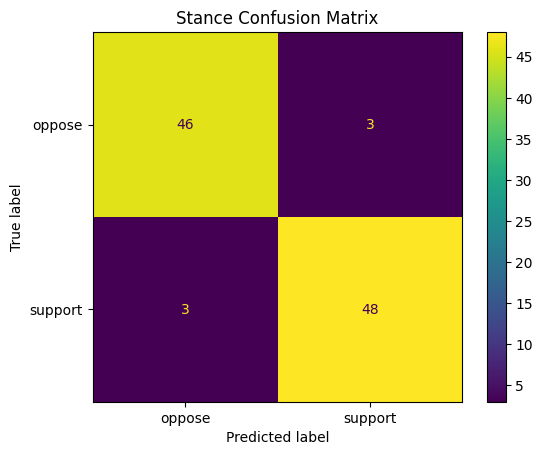

RELEVANCE CLASSIFICATION REPORT
                   precision    recall  f1-score   support

somewhat relevant       0.00      0.00      0.00        10
directly relevant       0.90      0.97      0.93        90

         accuracy                           0.87       100
        macro avg       0.45      0.48      0.47       100
     weighted avg       0.81      0.87      0.84       100



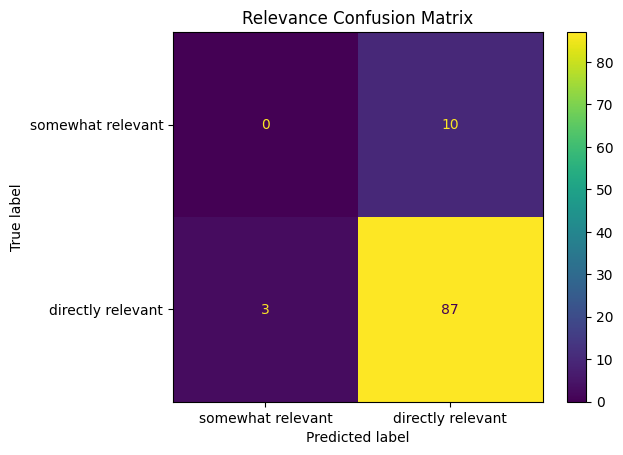

Saved predictions to annotated_test_with_predictions.csv


In [20]:
# Stance evaluation
stance_eval_df = test_df.dropna(subset=["gold_stance"]).copy()

print("STANCE CLASSIFICATION REPORT")
print(
    classification_report(
        stance_eval_df["gold_stance"],
        stance_eval_df["pred_stance"],
        target_names=["oppose", "support"],
        zero_division=0,
    )
)

cm_stance = confusion_matrix(
    stance_eval_df["gold_stance"],
    stance_eval_df["pred_stance"],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_stance,
    display_labels=["oppose", "support"],
)
disp.plot()
plt.title("Stance Confusion Matrix")
plt.show()

# Relevance evaluation
relevance_eval_df = test_df.dropna(subset=["gold_relevance"]).copy()

print("RELEVANCE CLASSIFICATION REPORT")
print(
    classification_report(
        relevance_eval_df["gold_relevance"],
        relevance_eval_df["pred_relevance"],
        target_names=["somewhat relevant", "directly relevant"],
        zero_division=0,
    )
)

cm_rel = confusion_matrix(
    relevance_eval_df["gold_relevance"],
    relevance_eval_df["pred_relevance"],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rel,
    display_labels=["somewhat relevant", "directly relevant"],
)
disp.plot()
plt.title("Relevance Confusion Matrix")
plt.show()

test_df.to_csv("annotated_test_with_predictions.csv", index=False)
print("Saved predictions to annotated_test_with_predictions.csv")


The model performed well on stance prediction, with balanced F1 scores for support and oppose. Relevance prediction was much weaker for the somewhat relevant class, likely because the derived training labels were highly imbalanced and because somewhat relevant is inherently more subjective than directly relevant. My annotated test set was also imbalanced, with 90 directly relevant examples and only 10 somewhat relevant examples, which likely made the minority class harder to learn and evaluate.